# limit_chart_network_analysis function demo

In [1]:
# Import libraries
from process_improvement.charts.limit_charts import limit_chart_network_analysis
from process_improvement.charts.utils import LimitChartNetworkAnalysisConfig as LCNAC

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# List example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create dataframe
df = load_example_data("eight_machine_manufacturing_process")

df = df.drop(['Machine 5 - Initial'], axis=1)

# initial_df = df[df['Stage'] == 'Initial']

df.head()

,Observation,Machine 1,Machine 2,Machine 3,Machine 4,Machine 5,Machine 6,Machine 7,Machine 8
0,1,6.64,5.97,6.20,4.59,5.96,5.34,5.50,4.87
1,2,5.07,5.48,6.22,4.13,5.69,5.83,5.65,5.15
2,3,5.13,5.58,6.57,5.36,6.03,5.28,5.90,5.58
3,4,4.75,7.28,6.77,5.78,6.40,6.28,4.78,6.24
4,5,6.11,6.14,6.58,3.49,5.65,4.97,5.21,5.55


In [4]:
# Melt the dataframe
df_melted = df.melt(
    id_vars="Observation",       # Column to keep
    var_name="Machine",          # New column name for original machine columns
    value_name="Length"          # New column name for the values
)
df_melted

,Observation,Machine,Length
0,1,Machine 1,6.64
1,2,Machine 1,5.07
2,3,Machine 1,5.13
3,4,Machine 1,4.75
4,5,Machine 1,6.11
...,...,...,...
315,36,Machine 8,6.16
316,37,Machine 8,6.02
317,38,Machine 8,5.46
318,39,Machine 8,4.92


In [5]:
unique_machines = df_melted['Machine'].unique().tolist()
unique_machines

['Machine 1',
 'Machine 2',
 'Machine 3',
 'Machine 4',
 'Machine 5',
 'Machine 6',
 'Machine 7',
 'Machine 8']

## Create list of dataframes

In [6]:
# Create list of dataframes using unique stages
df_list = [g.copy().reset_index(drop=True) for _, g in df_melted.groupby('Machine', sort=False)]

df_list[0].head()

,Observation,Machine,Length
0,1,Machine 1,6.64
1,2,Machine 1,5.07
2,3,Machine 1,5.13
3,4,Machine 1,4.75
4,5,Machine 1,6.11


## Specification Limits

In [7]:
USL = 8
LSL = 4
tolerance = USL - LSL
Target = 6

## Configuration and network analysis

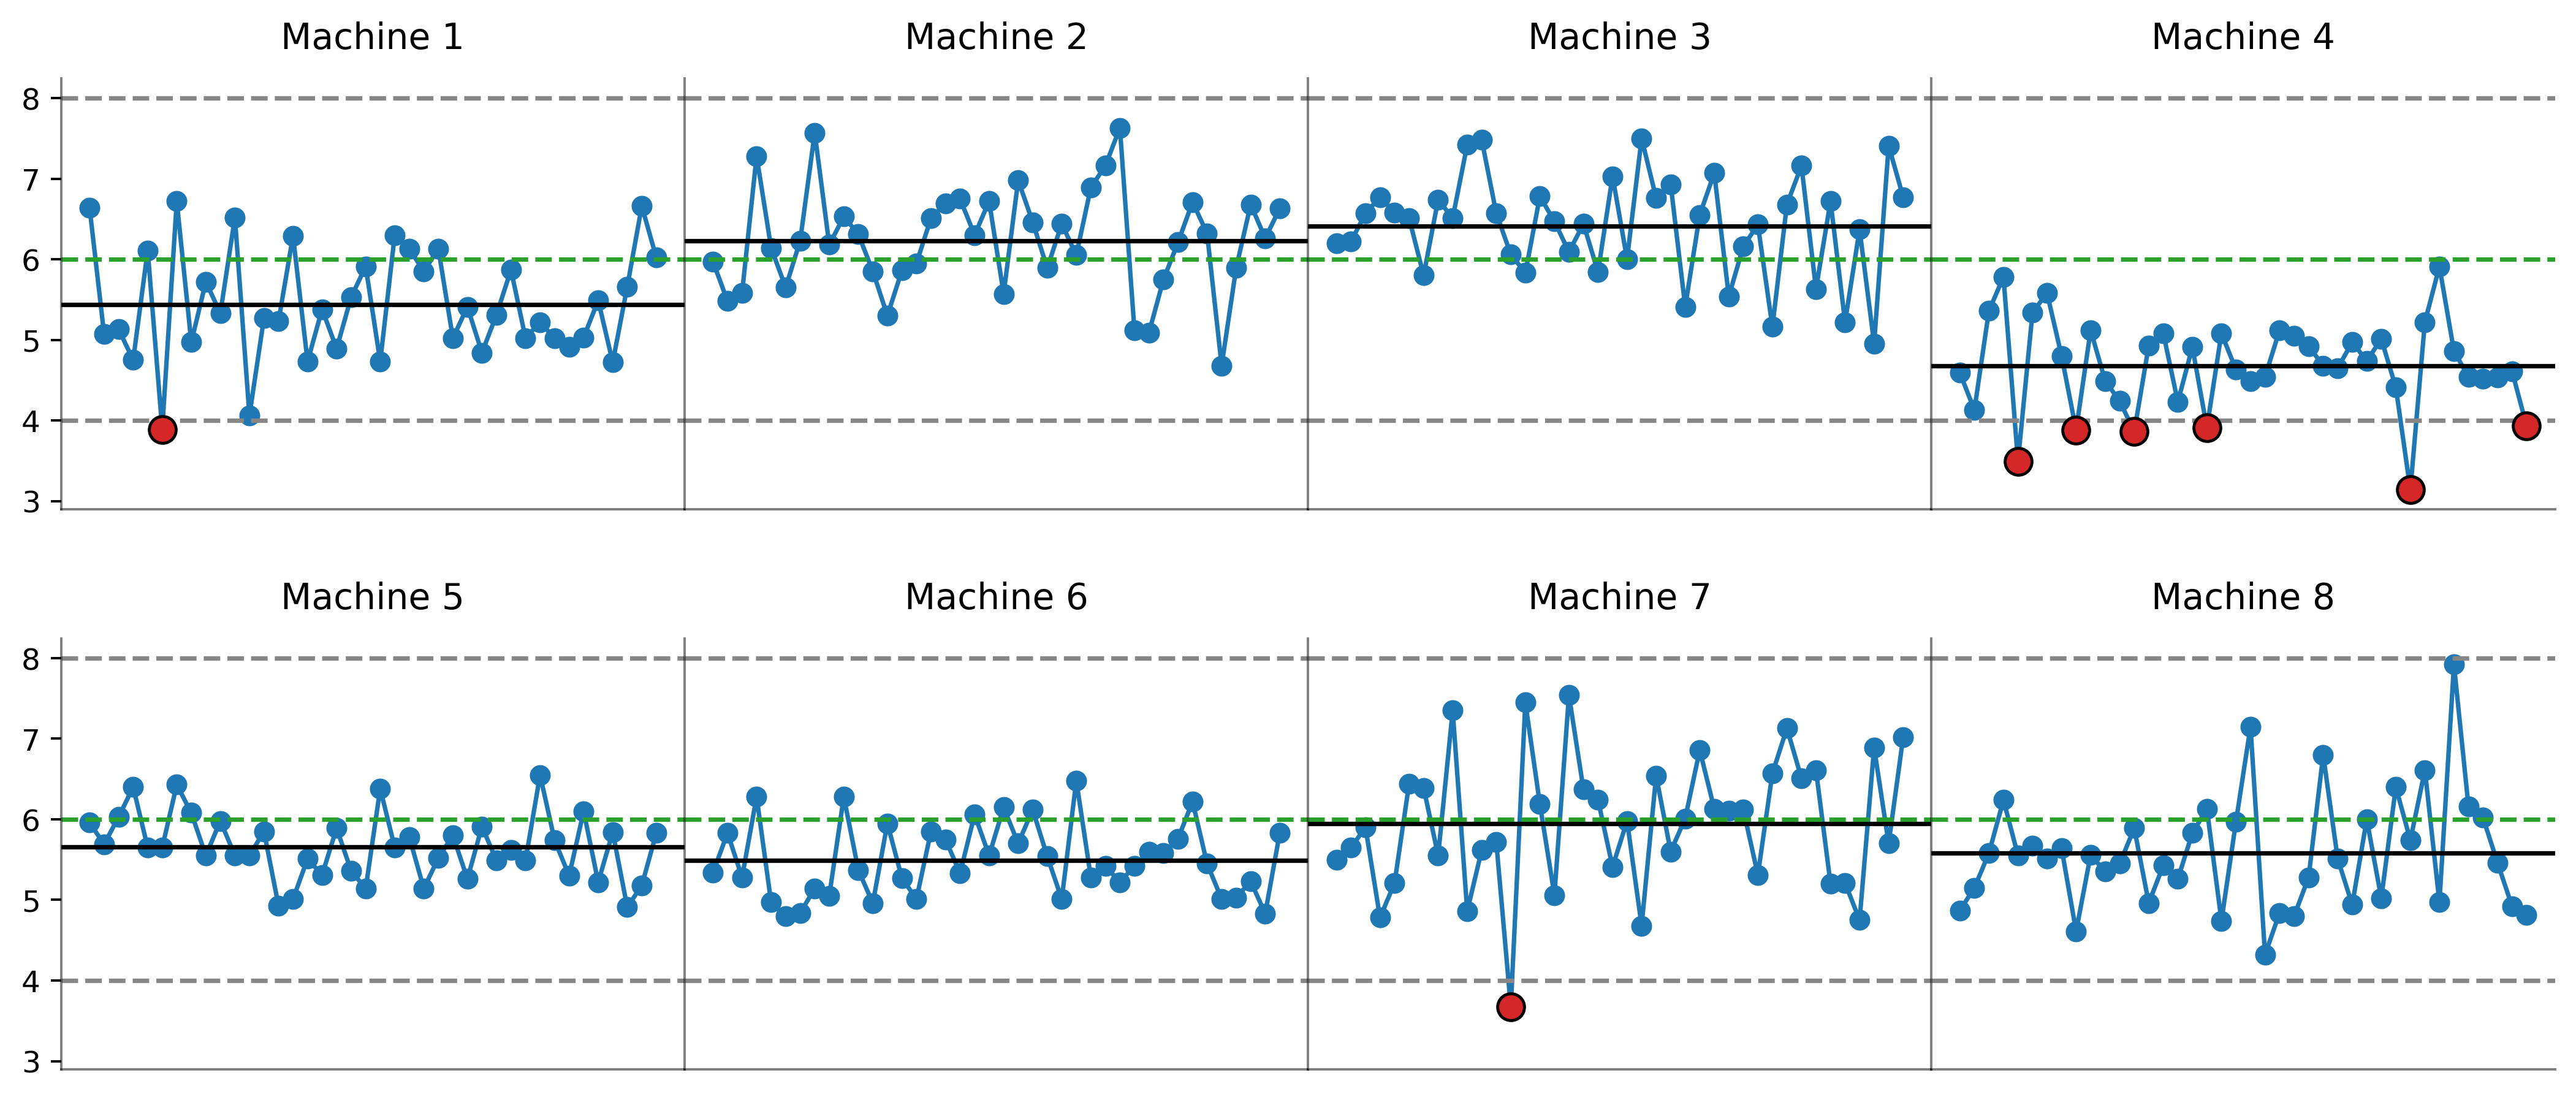

In [14]:
# Configuration
config = LCNAC(
    figsize=(15,6),
    tickinterval=10,
    show_mean=True,
    hspace=0.3
)

# Create XmR chart
results = limit_chart_network_analysis(
    df_list=df_list,
    values='Length',
    x_labels='Observation',
    nrows=2,
    ncols=4,
    USL=USL,
    LSL=LSL,
    Target=Target,
    subplot_titles=unique_machines,
    config=config
)

## Show process statistics

In [9]:
# Show statistics
round(results.stats_df, 2)

,Chart,Mean,USL,LSL,Above USL,Below LSL,Total Out of Spec
0,Dataset 1,5.44,8,4,0,1,1
1,Dataset 2,6.23,8,4,0,0,0
2,Dataset 3,6.41,8,4,0,0,0
3,Dataset 4,4.68,8,4,0,6,6
4,Dataset 5,5.66,8,4,0,0,0
5,Dataset 6,5.49,8,4,0,0,0
6,Dataset 7,5.95,8,4,0,1,1
7,Dataset 8,5.58,8,4,0,0,0


## Alternate configuration and limit chart network analysis

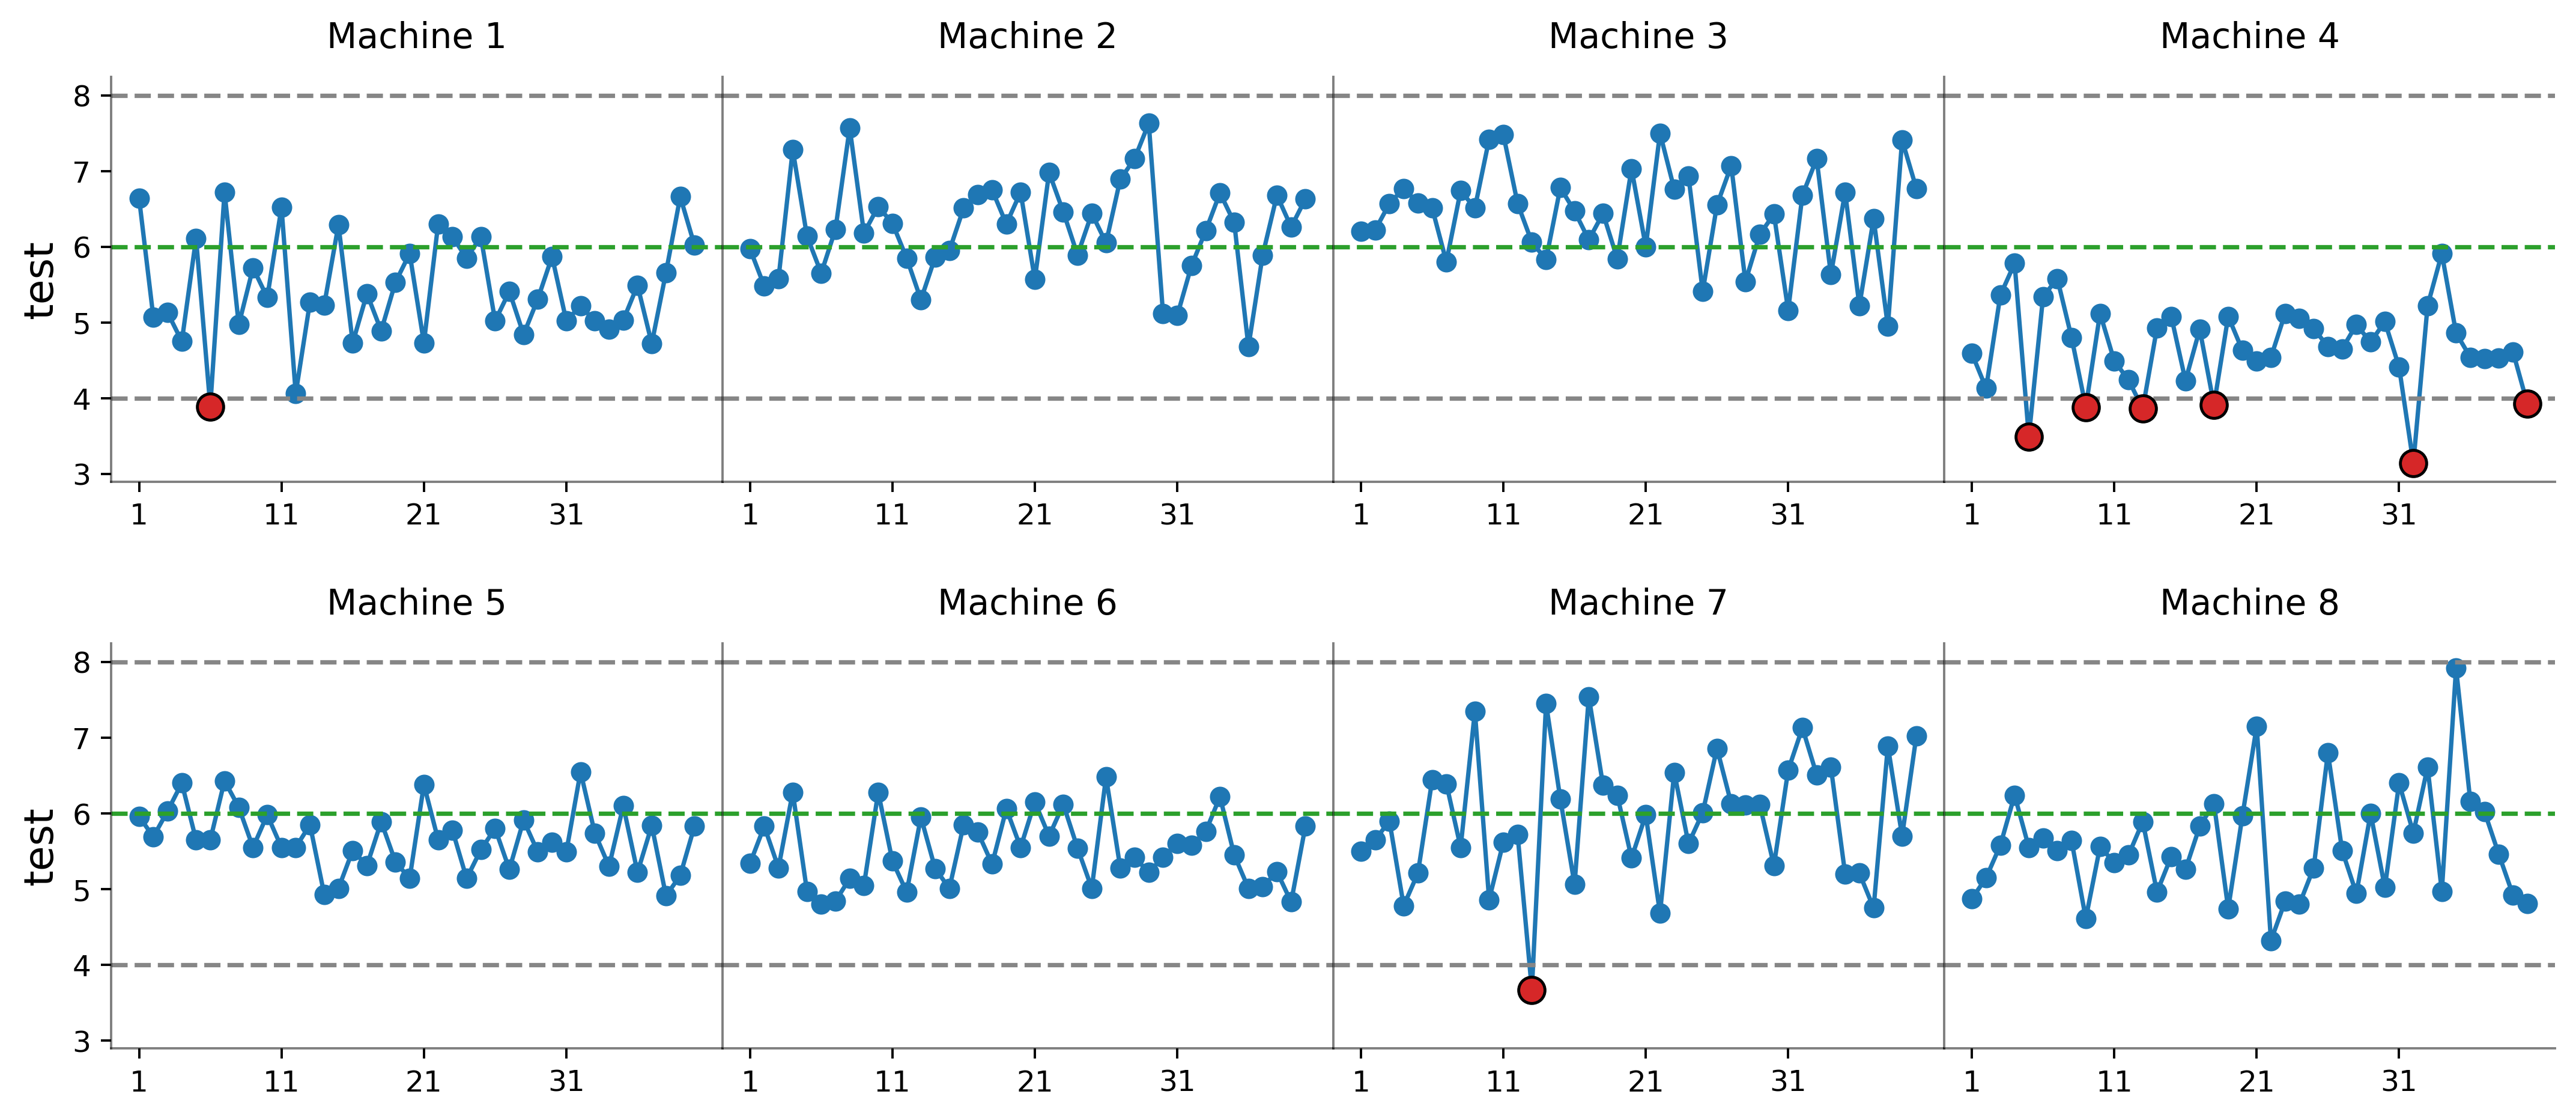

In [16]:
# Configuration
config2 = LCNAC(
    figsize=(15,6),
    tickinterval=10,
    show_mean=False,
    hspace=0.4,
    limit_chart_ylabel='test',
    limit_title_fontsize=12,
    ylabel_fontsize=14,
    show_xticks=True,
    show_yticks=True
)

# Create XmR chart
results = limit_chart_network_analysis(
    df_list=df_list,
    values='Length',
    x_labels='Observation',
    nrows=2,
    ncols=4,
    USL=USL,
    LSL=LSL,
    Target=Target,
    subplot_titles=unique_machines,
    config=config2
)